# The Silent Crisis in Global Healthcare

Around the world, millions of people seek medical care every day — but in many countries, the very facilities meant to heal them lack basic **hygiene services**. This report uses UNICEF data to expose the scale of this problem and its deep connection to economic inequality.

## Key Questions We Explore
- Which countries have the **worst hygiene** in health facilities?
- Is there a relationship between *GDP per capita* and hygiene quality?
- How has the situation changed **over time**?

In [18]:
#| label: setup
#| warning: false
#| message: false
#| echo: false

import pandas as pd
import geopandas as gpd
from plotnine import *
import warnings
warnings.filterwarnings('ignore')

# Load data
indicator1 = pd.read_csv('unicef_indicator_1.csv')
indicator2 = pd.read_csv('unicef_indicator_2.csv')
metadata   = pd.read_csv('unicef_metadata.csv')

# Rename metadata columns for easier use
metadata = metadata.rename(columns={
    'GDP per capita (constant 2015 US$)': 'gdp_per_capita',
    'Life expectancy at birth, total (years)': 'life_expectancy',
    'Population, total': 'population'
})

# Join indicator1 with metadata
merged = indicator1.merge(
    metadata[['country', 'year', 'gdp_per_capita', 'life_expectancy', 'population']],
    left_on=['country', 'time_period'],
    right_on=['country', 'year'],
    how='left'
)

print('Data loaded successfully!')
print(f'Indicator 1 shape: {indicator1.shape}')
print(f'Merged shape: {merged.shape}')

Data loaded successfully!
Indicator 1 shape: (613, 14)
Merged shape: (613, 18)


## Where Is the Problem Worst?

The map below reveals a stark geographic pattern. Countries across **Sub-Saharan Africa** and parts of **South Asia** show the highest proportions of health facilities with limited hygiene. These are also among the world's least economically developed regions.

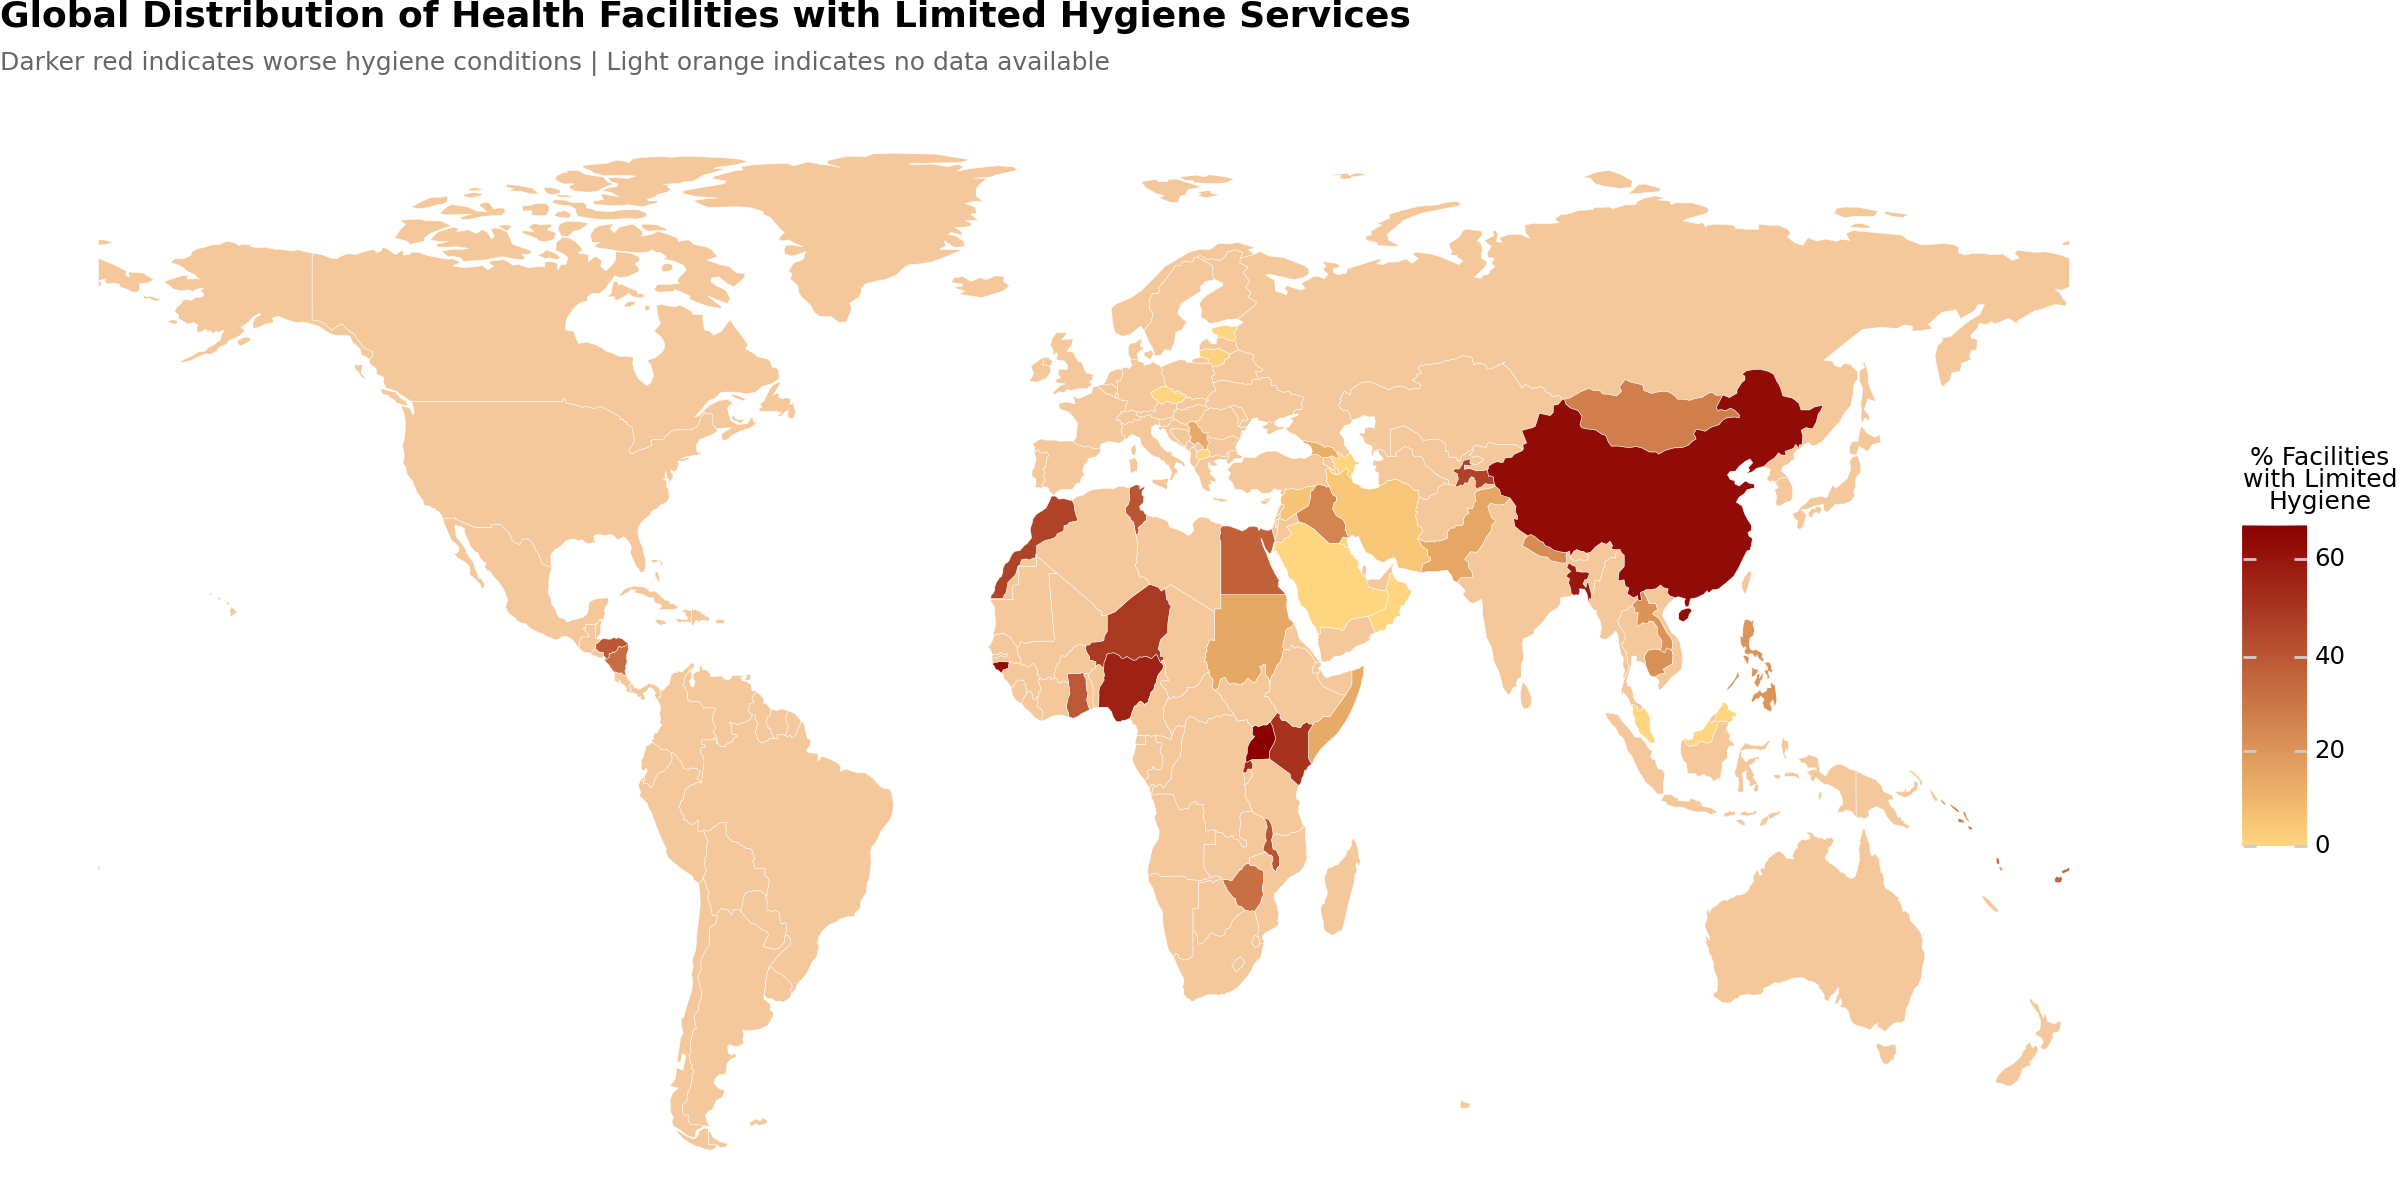

In [19]:
#| label: fig-worldmap
#| fig-cap: "Proportion of health facilities with limited hygiene by country (latest available year)"
#| warning: false
#| fig-width: 12
#| fig-height: 6

import geopandas as gpd
import pandas as pd  # ← ensures pd is available
from plotnine import *

# Reload data fresh in this cell
indicator1 = pd.read_csv('unicef_indicator_1.csv')

# Load world shapefile
url = 'https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip'
world = gpd.read_file(url)

# Remove Antarctica for cleaner look
world = world[world['SOVEREIGNT'] != 'Antarctica']

# Get latest obs_value per country
latest = (
    indicator1.dropna(subset=['obs_value'])
    .sort_values('time_period', ascending=False)
    .groupby('alpha_3_code', as_index=False)
    .first()[['alpha_3_code', 'obs_value']]
)

world_merged = world.merge(latest, left_on='ADM0_A3', right_on='alpha_3_code', how='left')

(
    ggplot(world_merged)
    + geom_map(aes(fill='obs_value'), color='white', size=0.1)
    + scale_fill_gradient(
        low='#FFD580',
        high='#8B0000',
        na_value='#F4C89A',
        name='% Facilities\nwith Limited\nHygiene'
    )
    + labs(
        title='Global Distribution of Health Facilities with Limited Hygiene Services',
        subtitle='Darker red indicates worse hygiene conditions | Light orange indicates no data available'
    )
    + theme_void()
    + theme(
        plot_title=element_text(size=13, weight='bold', margin={'b': 6}),
        plot_subtitle=element_text(size=9, color='#666666', margin={'b': 10}),
        legend_position='right',
        legend_title=element_text(size=9),
        figure_size=(12, 6)
    )
)

## The Worst-Affected Countries

While the map gives a global overview, the bar chart below zooms in on the **top 10 countries** most affected. These countries have critically high percentages — meaning the majority of their health facilities cannot guarantee basic hygiene to patients.

This has *direct consequences* for:
- **Maternal health** — women giving birth in unsafe conditions
- **Child mortality** — infections that could easily be prevented
- **Disease spread** — facilities that should stop illness instead spreading it

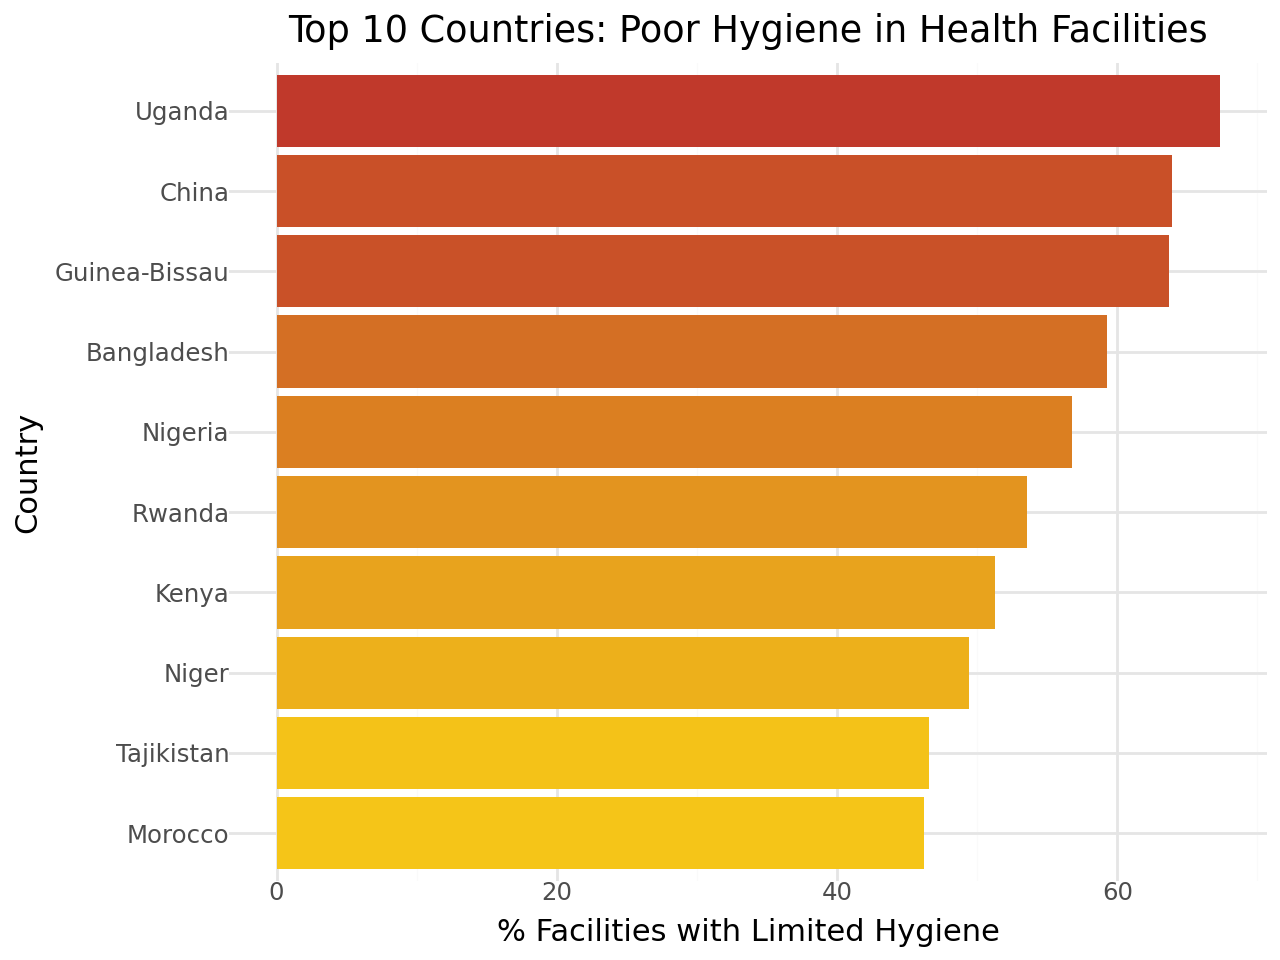

In [20]:
#| label: fig-bar
#| fig-cap: "Top 10 countries with the highest proportion of health facilities lacking hygiene"
#| warning: false

top10 = (
    indicator1.dropna(subset=['obs_value'])
    .sort_values('time_period', ascending=False)
    .groupby('country', as_index=False)
    .first()
    .sort_values('obs_value', ascending=False)
    .head(10)
)

(
    ggplot(top10, aes(x='reorder(country, obs_value)', y='obs_value', fill='obs_value'))
    + geom_col()
    + coord_flip()
    + scale_fill_gradient(low='#f5c518', high='#c0392b')
    + labs(
        title='Top 10 Countries: Poor Hygiene in Health Facilities',
        x='Country',
        y='% Facilities with Limited Hygiene'
    )
    + theme_minimal()
    + theme(legend_position='none')
)

## Does Wealth Explain the Gap?

The scatterplot below examines whether a country's **GDP per capita** predicts the quality of hygiene in its health facilities. The regression line confirms a *negative correlation* — as GDP rises, the proportion of facilities with limited hygiene falls.

However, the spread of data points shows that **economics alone does not tell the full story**. Some middle-income countries perform worse than expected, suggesting that *policy choices and governance* also play a critical role.

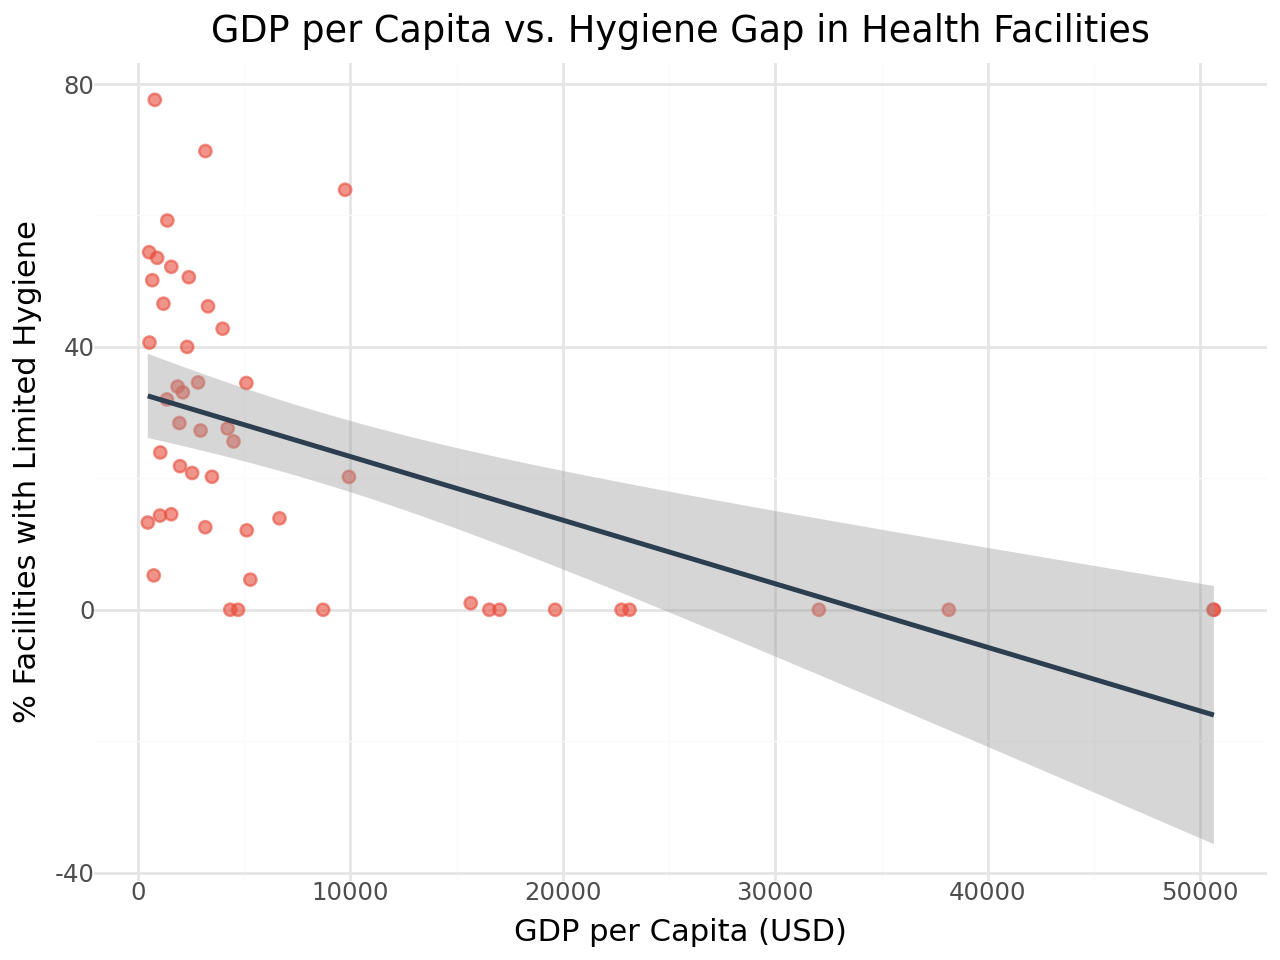

In [21]:
#| label: fig-scatter
#| fig-cap: "Relationship between GDP per capita and hygiene quality in health facilities"
#| warning: false

scatter_data = (
    merged.dropna(subset=['obs_value', 'gdp_per_capita'])
    .groupby('country', as_index=False)
    .agg({'obs_value': 'mean', 'gdp_per_capita': 'mean'})
)

(
    ggplot(scatter_data, aes(x='gdp_per_capita', y='obs_value'))
    + geom_point(color='#e74c3c', alpha=0.6, size=2)
    + geom_smooth(method='lm', color='#2c3e50', se=True)
    + labs(
        title='GDP per Capita vs. Hygiene Gap in Health Facilities',
        x='GDP per Capita (USD)',
        y='% Facilities with Limited Hygiene'
    )
    + theme_minimal()
)

## Has the Situation Improved Over Time?

The time-series chart tracks the **global average** of health facilities with limited hygiene across all available years. A downward trend would indicate progress — but as the chart shows, improvement has been *slow and uneven*.

For millions of people in the most vulnerable countries, the pace of change is simply **not fast enough**.

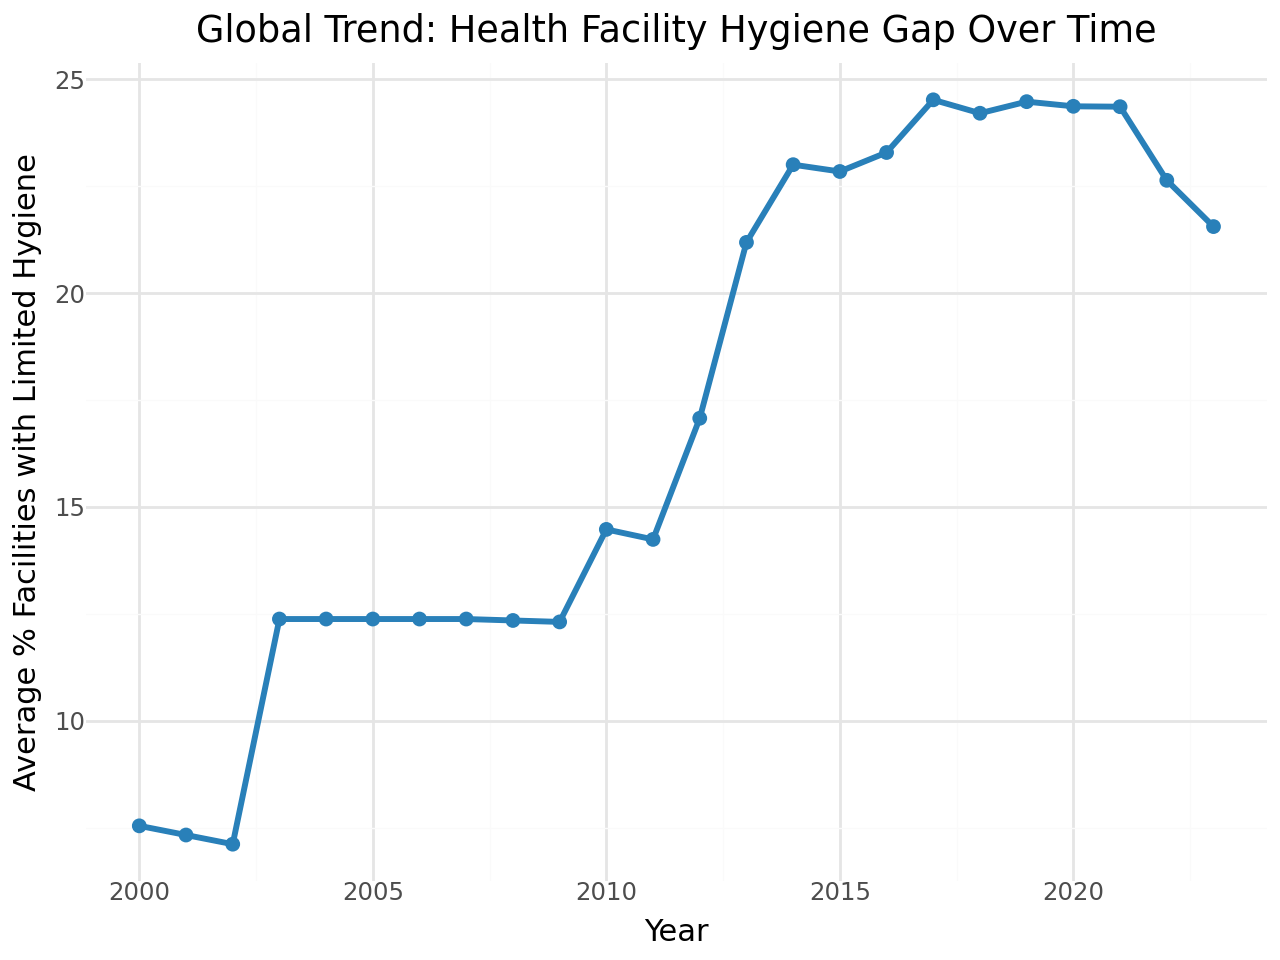

In [22]:
#| label: fig-timeseries
#| fig-cap: "Global average of health facilities with limited hygiene over time"
#| warning: false

time_data = (
    indicator1.dropna(subset=['obs_value'])
    .groupby('time_period', as_index=False)
    .agg({'obs_value': 'mean'})
    .rename(columns={'obs_value': 'avg_value'})
    .sort_values('time_period')
)

(
    ggplot(time_data, aes(x='time_period', y='avg_value'))
    + geom_line(color='#2980b9', size=1.2)
    + geom_point(color='#2980b9', size=2)
    + labs(
        title='Global Trend: Health Facility Hygiene Gap Over Time',
        x='Year',
        y='Average % Facilities with Limited Hygiene'
    )
    + theme_minimal()
)

## Conclusion

The data tells a clear story: **access to hygienic healthcare is still a privilege**, not a universal right. The countries that need the most support — those with the lowest GDPs and highest disease burdens — are also the ones where health facility hygiene is worst.

UNICEF's work in this space is critical. But awareness is the first step. By understanding *where* the problem is concentrated and *why* it persists, policymakers, donors, and citizens can push for the targeted investments that will save lives.

---
*Data source: UNICEF Global Databases, World Bank Development Indicators*